In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import netCDF4
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear

In [2]:
# fetch selected dates
start_date, end_date = ('2020-02-01', '2021-08-31')
start_date, end_date

('2020-02-01', '2021-08-31')

In [5]:
#  print selected area bbox
bbox = (11.336505, 58.244635, 11.489554, 58.325851)
bbox

(11.336505, 58.244635, 11.489554, 58.325851)

In [6]:
# # Load data for May - August 2021
min_lon, min_lat, max_lon, max_lat = bbox

# Define resolution
resolution = 0.003   # use the lowest resolution in the dataset collection

dask_chunks={'time': -1}
# Define time range
time_range = (start_date, end_date)
time_horizon     = pd.date_range(start=start_date, end=end_date, freq='1d')
time_horizon_len = len(time_horizon)
print(f"Simulation period: {time_horizon[0].date()} → {time_horizon[-1].date()}  ({time_horizon_len} days)")
time_horizon_len

Simulation period: 2020-02-01 → 2021-08-31  (578 days)


578

In [7]:
from extract_filled_grid import load_filled_grid

combined_data = load_filled_grid(
    bbox=bbox,
    time_range=time_range,
    # resolution=0.125,
    resolution=resolution,
    verbose=True
)
combined_data

Loading SSS (cmems_sss)...
  SSS loaded in 3.4s
Loading SST (s3_slstr_sst)...
  SST loaded in 18.0s
Loading CHL (cmems_chl_tur)...
  CHL loaded in 1.0s
Reference grid: 29 lat x 53 lon @ 0.003 deg
Daily horizon: 2020-02-01 -> 2021-08-31 (578 days)
Regridding each variable (gaps preserved as NaN)...
Computing regridded arrays...
  Compute done in 930.7s
Starting DINEOF gap-filling...
  Processing salinity...
    Data shape: 578 time steps x 1537 ocean points
    Initial coverage: 840739/888386 (94.64%)
    Cross-validation: 42036 points withheld (5.0%)
    Determining optimal number of EOF modes...
    Optimal number of modes: 3
    Starting DINEOF iterations (max: 100)...
    Converged at iteration 5 (CV-RMSE = 0.016381)
    Final coverage (ocean only): 100.00%
  Processing temperature...
    Data shape: 578 time steps x 1071 ocean points
    Initial coverage: 67353/619038 (10.88%)
    Cross-validation: 3367 points withheld (5.0%)
    Determining optimal number of EOF modes...
    Optim

<xarray.Dataset> Size: 11MB
Dimensions:      (time: 578, latitude: 29, longitude: 53)
Coordinates:
  * time         (time) datetime64[ns] 5kB 2020-02-01 2020-02-02 ... 2021-08-31
  * latitude     (latitude) float64 232B 58.33 58.33 58.32 ... 58.25 58.25 58.24
  * longitude    (longitude) float64 424B 11.34 11.34 11.34 ... 11.49 11.49
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float32 4MB 28.5 28.49 ... 24.43
    temperature  (time, latitude, longitude) float32 4MB nan nan nan ... nan nan
    chlorophyll  (time, latitude, longitude) float32 4MB nan nan nan ... nan nan
    ocean_mask   (latitude, longitude) bool 2kB False False ... False False

In [8]:
ds_daily = combined_data
ds_daily = combined_data.rename({"chlorophyll": "Chl"})
ds_daily

<xarray.Dataset> Size: 11MB
Dimensions:      (time: 578, latitude: 29, longitude: 53)
Coordinates:
  * time         (time) datetime64[ns] 5kB 2020-02-01 2020-02-02 ... 2021-08-31
  * latitude     (latitude) float64 232B 58.33 58.33 58.32 ... 58.25 58.25 58.24
  * longitude    (longitude) float64 424B 11.34 11.34 11.34 ... 11.49 11.49
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float32 4MB 28.5 28.49 ... 24.43
    temperature  (time, latitude, longitude) float32 4MB nan nan nan ... nan nan
    Chl          (time, latitude, longitude) float32 4MB nan nan nan ... nan nan
    ocean_mask   (latitude, longitude) bool 2kB False False ... False False

In [9]:
INPUT_FILE = "gridded_input_insitu_compare.nc"

In [10]:

# SAVE COMBINED DATACUBE TO NETCDF
print(f"Saving combined datacube to: {INPUT_FILE}")
print(f"Dataset info before saving:")
print(f"  Variables: {list(ds_daily.data_vars)}")
print(f"  Time steps: {len(ds_daily.time)}")
print(
    f"  Spatial extent: "
    f"lat {ds_daily.latitude.values.min():.3f} to {ds_daily.latitude.values.max():.3f}, "
    f"lon {ds_daily.longitude.values.min():.3f} to {ds_daily.longitude.values.max():.3f}"
)


# Remoe CF encoding attributes that xarray will recreate
ds_to_save = ds_daily.copy()
for attr in ["units", "calendar"]:
    ds_to_save.time.attrs.pop(attr, None)

# Clear any existing encoding that may conflict
ds_to_save.time.encoding = {}

# Compression settings
encoding = {
    var: {
        "zlib": True,
        "complevel": 4,
        "dtype": "float32",
    }
    for var in ds_to_save.data_vars
}

# Explicit encoding for the time coordinate
encoding["time"] = {
    "units": "days since 1970-01-01 00:00:00",
    "calendar": "proleptic_gregorian",
}


# Save dataset
ds_to_save.to_netcdf(
    INPUT_FILE,
    engine="h5netcdf",
    encoding=encoding,
    compute=True,
)

print(f"✓ Successfully saved to {INPUT_FILE}")
print(f"  File size: {os.path.getsize(INPUT_FILE) / 1024**2:.2f} MB")

Saving combined datacube to: gridded_input_insitu_compare.nc
Dataset info before saving:
  Variables: ['salinity', 'temperature', 'Chl', 'ocean_mask']
  Time steps: 578
  Spatial extent: lat 58.245 to 58.329, lon 11.337 to 11.493
✓ Successfully saved to gridded_input_insitu_compare.nc
  File size: 3.72 MB


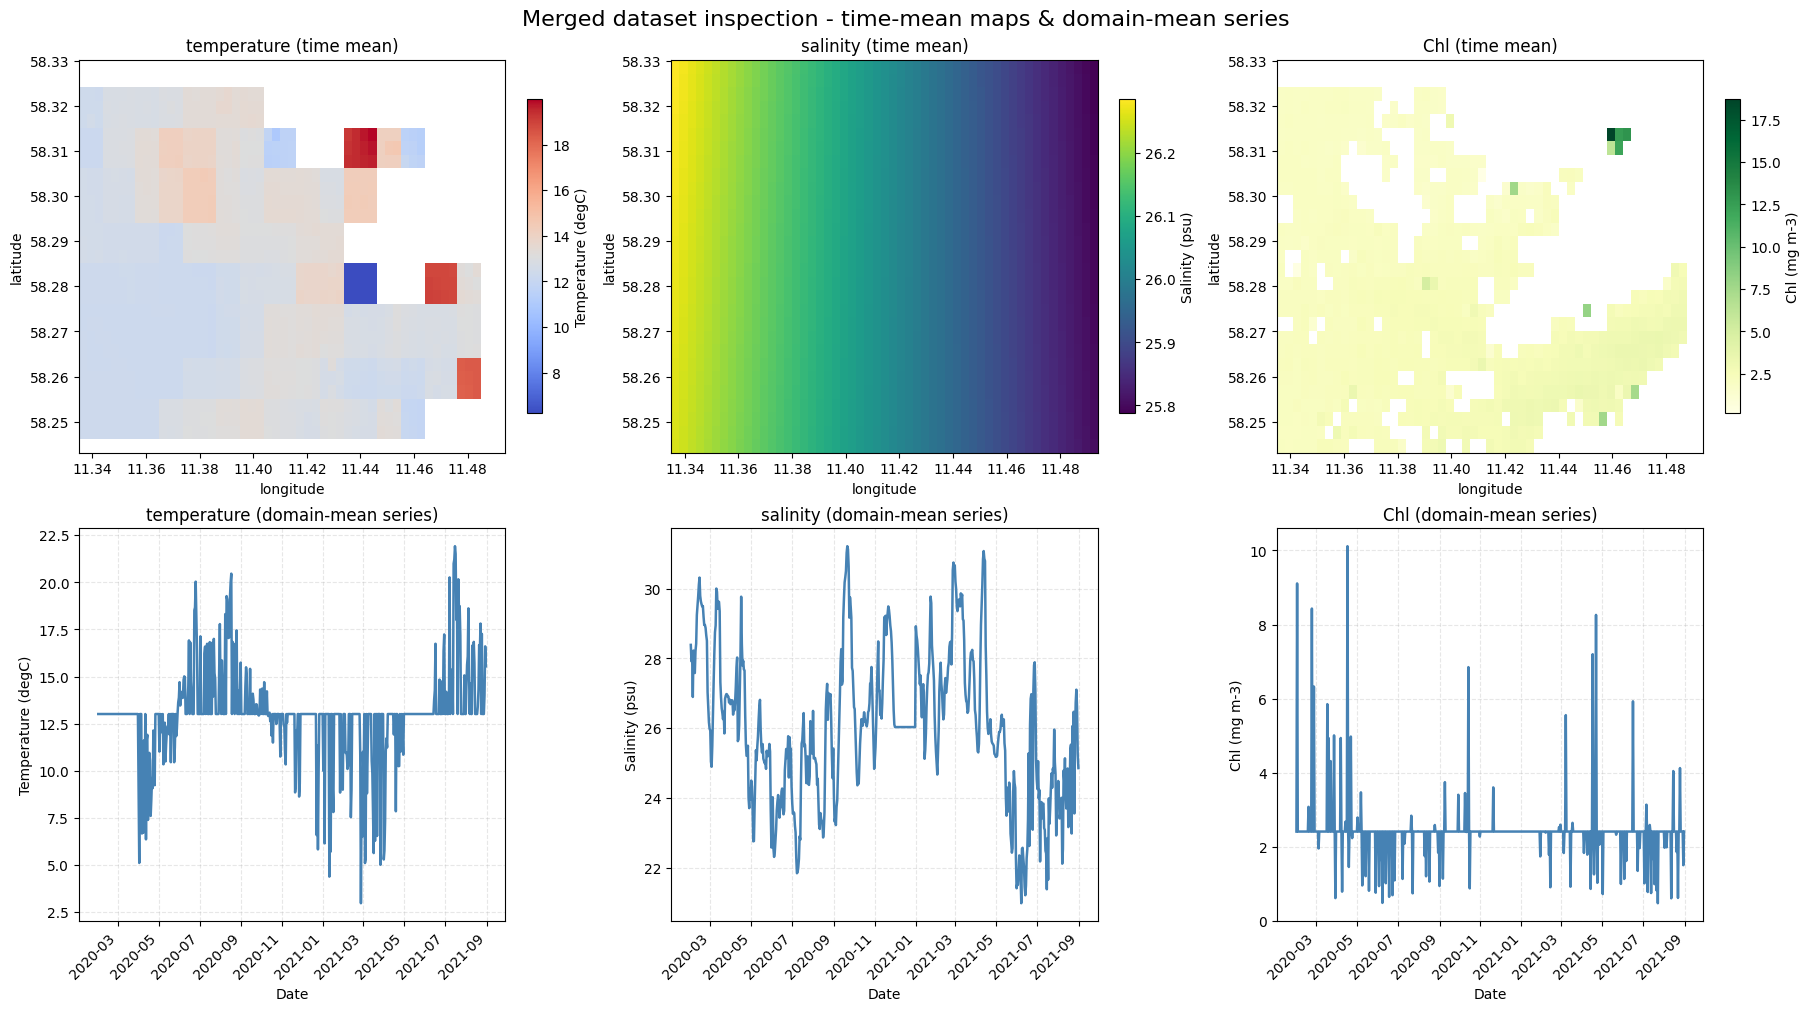

In [23]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Inspect the combined cube before running the model.
#   Top row    : spatial time-mean maps  (geographic pattern per variable)
#   Bottom row : domain-mean daily series (temporal variability per variable)

# ds_daily = combined_data

vars_to_plot = [
    ("temperature", "Temperature (degC)", "coolwarm"),
    ("salinity",    "Salinity (psu)",     "viridis"),
    ("Chl",  "Chl (mg m-3)",       "YlGn"),
]

if ds_daily is None or 'time' not in ds_daily.dims:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    for col, (var, label, cmap) in enumerate(vars_to_plot):
        ax_map, ax_ts = axes[0, col], axes[1, col]

        if var not in ds_daily:
            ax_map.text(0.5, 0.5, f"{var} not found", ha='center')
            ax_ts.text(0.5, 0.5, f"{var} not found", ha='center')
            continue

        da = ds_daily[var]

        # --- top: spatial time-mean map ---
        da.mean(dim='time').plot(
            ax=ax_map, cmap=cmap, add_colorbar=True,
            cbar_kwargs={'shrink': 0.8, 'label': label},
        )
        ax_map.set_title(f"{var} (time mean)")
        ax_map.set_xlabel("longitude")
        ax_map.set_ylabel("latitude")

        # --- bottom: domain-mean daily time series ---
        ts = da.mean(dim=['latitude', 'longitude'])
        ax_ts.plot(ds_daily['time'], ts, color='steelblue', lw=1.8)
        ax_ts.set_title(f"{var} (domain-mean series)")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel(label)
        ax_ts.grid(True, alpha=0.3, ls='--')
        for t in ax_ts.get_xticklabels():
            t.set_rotation(45)
            t.set_ha('right')

    plt.suptitle("Merged dataset inspection - time-mean maps & domain-mean series",
                 fontsize=16)
    # plt.savefig("ds_daily_inspection.png", dpi=150)
    plt.show()

In [12]:
# ============================================================
# RECHUNK FOR OPTIMAL DASK PERFORMANCE
# ============================================================
# After subsetting and interpolation, Dask's internal chunk
# boundaries may be irregular. Rechunking reorganises them into
# uniform tiles:
#   time: -1  -> one chunk for the full time axis (required;
#               ShellSIM cannot be split along time)
#   lat: 80, lon: 110 -> spatial tile footprint
# After rechunking each Dask task processes one complete tile
# with no overlap, minimising scheduler overhead.
#
# RAM tip: if you encounter MemoryErrors, halve lat/lon chunk
# sizes. Each chunk ~ lat * lon * time_steps * 8 bytes * n_vars.

# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size


# large_dataset
# dataset_chunk = {'time': -1, 'latitude': 18, 'longitude': 35}

# small dataset
dataset_chunk = {'time': -1, 'latitude': -1, 'longitude': -1}

print("Rechunking dataset for optimal performance")
# Force Dask backing AND explicit spatial tiling.
# time stays as ONE chunk (ShellSIM cannot be split along time);
# latitude/longitude are tiled so each Dask task = one spatial tile.
# ds_daily = ds_daily.chunk({
#     'time': -1,        # whole time axis (required — ShellSIM can't split time)
#     'latitude': 18,    # 35 -> 2 tiles (18 + 17)
#     'longitude': 35,   # 69 -> 2 tiles (35 + 34)
# })

# if  whole cube is ~30 MB, one tile is also perfectly fine and simplest:
ds_daily = ds_daily.chunk(dataset_chunk)

print("Rechunked dataset")
print("Is dask-backed:", bool(ds_daily.chunks))   # should print True
print(ds_daily.chunks)

# and gives 4 roughly equal tiles.




Rechunking dataset for optimal performance
Rechunked dataset
Is dask-backed: True
Frozen({'time': (578,), 'latitude': (29,), 'longitude': (53,)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [13]:
PYFABM_MODEL_CONFIG="/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/notebook_dropdowns/final_working_versions/partial_fabm.yaml"

In [14]:
# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
# N_STATES  = 11 : internal state variables integrated by pyfabm
# N_DIAGS   =  2 : diagnostic outputs (TFW, SL) — from pyfabm
#                  diagnostic_variables, NOT part of model.state
# N_OUTPUTS = 13 : total rows returned per pixel (states + diags)
#
# VARIABLE_NAMES order MUST exactly match the row order filled
# inside the time loop: rows 0–10 = 11 state variables,
# row 11 = TFW, row 12 = SL.
#
# run_fabm_at_point_full (fixes applied):
#   1. Uses len(T_ts) instead of outer-scope time_horizon_len so
#      the function is self-contained and safe in Dask workers.
#   2. Clamps food concentrations (Chl/POC/POM/TPM) to >= 0.
#      Negative concentrations from bad/fake data cause forward-
#      Euler to diverge within a few steps.
#   3. Updates number_of_days_since_start_of_the_year every step
#      so seasonal physiology is correct across the full period.
#   4. redirect_stdout now covers the ENTIRE function body so
#      all FABM print output goes to the log file, not stdout.
# ============================================================

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

N_STATES  = 8   # pyfabm internal state variables (model.state[:] length)
N_DIAGS   = 2    # diagnostic outputs: TFW (row 11), SL (row 12)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 — total rows returned per pixel

# Authoritative names list — length must equal N_OUTPUTS (13).
# Method 2 imports this directly; do NOT redefine STATE_NAMES elsewhere.
VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 
    'aging', 
    'C1',
    'C2', 
    'C3',
    'Chl_state', 
    # 'POC_state', 
    # 'POM_state', 
    # 'TPM_state',
    
    'O2',  # rows 0–10
    'TFW', 
    'SL'# rows 11–12
]

assert len(VARIABLE_NAMES) == N_OUTPUTS, (
    f"VARIABLE_NAMES has {len(VARIABLE_NAMES)} entries but N_OUTPUTS={N_OUTPUTS}"
)


def run_fabm_at_point_full(T_ts, S_ts, Chl_ts,
                           # POC_ts=None, POM_ts=None, TPM_ts=None,
                           log_filename=None
                          ):

    """
    Runs the FABM/ShellSIM time-loop for a single spatial pixel.

    Parameters
    ----------
    T_ts, S_ts          : 1-D float arrays, length n_steps
        Temperature (°C) and practical salinity (PSU) time series.
    Chl_ts, POC_ts,
    POM_ts, TPM_ts      : 1-D float arrays, length n_steps
        Food-variable time series (mg m-3).  Values < 0 are clamped
        to 0 before being passed to the model (negative concentrations
        are unphysical and cause forward-Euler divergence).
    log_filename        : str
        Path to the append-mode log file that receives all FABM
        print/diagnostic output (keeps Jupyter stdout clean).

    Returns
    -------
    numpy.ndarray, shape (N_OUTPUTS=13, n_steps)
        Rows  0–10 : pyfabm state variables (model.state[:])
        Row  11    : TFW  diagnostic [g]
        Row  12    : Shell Length diagnostic [cm]
        All-NaN on land pixels or when any input is NaN / non-finite.
    """
    # ── n_steps is taken directly from the input arrays, NOT from the
    #    outer-scope time_horizon_len, so this function is safe to call
    #    from Dask workers that were serialised with a stale closure. ──
    n_steps = len(T_ts)




    # ── Guard: reject land / missing-data pixels ────────────────────
    all_inputs = [T_ts, S_ts, Chl_ts,
                  # POC_ts, POM_ts, TPM_ts
                 
                 ]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)

    # ── Clamp food concentrations to physically valid range ─────────
    # Negative concentrations are unphysical (artefacts of linear
    # interpolation or fake test data).  Passing them to the model
    # causes the forward-Euler integration to diverge within a few
    # steps, producing NaN or runaway values for the entire run.
    Chl_ts  = np.maximum(Chl_ts,  0.0)
    # POC_ts  = np.maximum(POC_ts,  0.0)
    # POM_ts  = np.maximum(POM_ts,  0.0)
    # TPM_ts  = np.maximum(TPM_ts,  0.0)

    try:
        # ── redirect_stdout covers the FULL function body so that
        #    pyfabm print output during both init AND getRates() goes
        #    to the log file rather than flooding Jupyter output. ────
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):
                    
                model = pyfabm.Model(PYFABM_MODEL_CONFIG)

                # ── Static (time-invariant) dependencies ────────────
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value  = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value  = 0.0

                # ── Initialise from day-0 forcing values ─────────────
                model.dependencies["temperature"].value        = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                    pd.Timestamp(time_horizon[0]).dayofyear
                )
                model.findStateVariable('Chl1/Chl').value = float(Chl_ts[0])
                # model.findStateVariable('POC1/POC').value = float(POC_ts[0])
                # model.findStateVariable('POM1/POM').value = float(POM_ts[0])
                # model.findStateVariable('TPM1/TPM').value = float(TPM_ts[0])

                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")
                
                if model.state[:].size != N_STATES:
                    raise ValueError(   # not RuntimeError → not caught below → surfaces loudly
                        f"YAML produces {model.state[:].size} states but N_STATES={N_STATES} "
                        f"— check which prey modules are active in partial_fabm.yaml"
                    )

                # ── Output array ─────────────────────────────────────
                outputs = np.zeros((N_OUTPUTS, n_steps))

                for nd in range(n_steps):
                    # ── Update day-of-year (drives seasonal physiology) ──
                    model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                        pd.Timestamp(time_horizon[nd]).dayofyear
                    )

                    # ── Update environmental forcings ────────────────
                    model.dependencies["temperature"].value        = float(T_ts[nd])
                    model.dependencies["practical_salinity"].value = float(S_ts[nd])
                    model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
                    # model.findStateVariable('POC1/POC').value      = float(POC_ts[nd])
                    # model.findStateVariable('POM1/POM').value      = float(POM_ts[nd])
                    # model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[nd])

                    # ── Forward-Euler step (same as original 1-D notebook) ──
                    state_rates = model.getRates()
                    model.state[:] += state_rates * 86400.0

                    # ── Guard: catch state blow-up immediately ────────────
                    # If any state variable is NaN or Inf (e.g. from a cube-
                    # root / log of a negative energy reserve when the oyster
                    # starves), pyfabm silently propagates bad values for all
                    # remaining steps without raising an exception.
                    # Detect it here, fill remaining outputs with NaN, and
                    # break — this preserves the valid data already computed
                    # up to this timestep rather than discarding it.
                    if not np.all(np.isfinite(np.array(model.state[:]))):
                        outputs[:, nd:] = np.nan
                        break

                    # ── Store state variables (rows 0–10) ────────────
                    outputs[:N_STATES, nd] = np.array(model.state[:])

                    # ── Store diagnostics (rows 11–12) ───────────────
                    outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
                    outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        return outputs  # shape (N_OUTPUTS=13, n_steps)

    except RuntimeError:
        warnings.warn(f"FABM failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

    except Exception as e:
        warnings.warn(f"FABM error at pixel: {str(e)}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

In [15]:
time_horizon_len = ds_daily.time.size
output_file_name = "gridded_output_insitu_compare.nc"

In [16]:
# ============================================================
# METHOD 1 —  RUN For Small area 
# ============================================================

# ============================================================
# MATERIALISE FORCING INPUTS BEFORE GOING DISTRIBUTED
# ============================================================
# datacube.load returns arrays whose Dask graph holds lazy
# rasterio/odc reader objects (a lambda + a weakref). The default
# threaded scheduler never pickles them, but dask.distributed MUST
# pickle the graph to ship it to worker PROCESSES -> that is the
# "Can't pickle ... <lambda>" / "cannot pickle weakref" crash.
#

# force the local scheduler on this compute
ds_daily = (
    ds_daily[['temperature', 'salinity', 'Chl']]
    .drop_vars('spatial_ref', errors='ignore')
    .compute(scheduler='synchronous')   # <-- bypass the already-active distributed Client
    .chunk(dataset_chunk)
)
dataset_chunks = dict(ds_daily.chunks)

preffered_chunksize = (1, dataset_chunks['latitude'][0], dataset_chunks['longitude'][0])
print('Inputs materialised and rechunked:', dataset_chunks)
print('Chunksize:', preffered_chunksize)



Inputs materialised and rechunked: {'time': (578,), 'latitude': (29,), 'longitude': (53,)}
Chunksize: (1, 29, 53)


In [17]:
# ============================================================
# METHOD 1: APPLY_UFUNC — PARALLEL SPATIAL APPLICATION
# ============================================================
# xr.apply_ufunc applies run_fabm_at_point_full across every
# (lat, lon) pixel in parallel via Dask.
#
# Key settings:
#   input_core_dims=[['time']]*6 : time is the 'core' dimension
#     consumed by the function; Dask parallelises over lat x lon.
#   output_core_dims=[['state','time']] : wrapper returns (13,T).
#   vectorize=True : loops pixel-by-pixel (needed for pyfabm).
#   dask='parallelized' : each spatial chunk becomes a Dask task.
#
# --- WHY dask.distributed WITH PROCESSES ---
# pyfabm holds C-level global state and is NOT thread-safe.
# Using process-based workers gives each worker its own memory
# space and its own pyfabm instance, preventing race conditions.
# n_workers=4, threads_per_worker=2 gives 8 concurrent slots;
# adjust n_workers to match your CPU count (cpu_count // 2).

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"


from dask.distributed import Client

# Start process-based local cluster (thread-safe for pyfabm)
# IMPORTANT: threads_per_worker MUST be 1.
# pyfabm has C-level global state that is NOT thread-safe.
# Two concurrent pyfabm instances in the SAME process (threads)
# will corrupt each other's model state silently.
client = Client(n_workers=4, threads_per_worker=1, processes=True)
print('Dask dashboard:', client.dashboard_link)

print('Setting up parallel computation with apply_ufunc ...')



# run ONCE before the dask/apply_ufunc call, not inside the wrapper
_m = pyfabm.Model(PYFABM_MODEL_CONFIG)
assert _m.state[:].size == N_STATES, (
    f"YAML produces {_m.state[:].size} states but N_STATES={N_STATES} "
    f"— check which prey modules are active in partial_fabm.yaml"
)
del _m


result_full = xr.apply_ufunc(
    run_fabm_at_point_full,
    ds_daily['temperature'],   
    ds_daily['salinity'],
    ds_daily['Chl'],
    # ds_daily['POC'],
    # ds_daily['POM'],
    # ds_daily['TPM'],
    input_core_dims=[['time']] * 3,
    output_core_dims=[['state', 'time']],
    exclude_dims=set(('time',)),
    dask='parallelized',
    vectorize=True,
    output_dtypes=[float],
    kwargs={'log_filename': RUN_LOG_FILENAME},
    dask_gufunc_kwargs={
        'allow_rechunk': True,
        'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
    }
)

# Restore coordinate labels on the output dimensions
result_full = result_full.assign_coords(time=time_horizon)
result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# Promote 'state' coordinate slices into separate Dataset variables
result_dataset = result_full.to_dataset(dim='state')

# Attach CF-convention metadata attributes
result_dataset['soft_tissue_energy'].attrs = {'units': 'J', 'long_name': 'Soft Tissue Energy'}
result_dataset['shell_energy'].attrs = {'units': 'J', 'long_name': 'Shell Energy'}
result_dataset['aging'].attrs = {'units': 'days', 'long_name': 'Aging'}
result_dataset['C1'].attrs = {'units': '', 'long_name': 'C1 State Variable'}
result_dataset['C2'].attrs = {'units': '', 'long_name': 'C2 State Variable'}
result_dataset['C3'].attrs = {'units': '', 'long_name': 'C3 State Variable'}
result_dataset['Chl_state'].attrs = {'units': 'mg/m3', 'long_name': 'Chlorophyll State'}
# result_dataset['POC'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Carbon State'}
# result_dataset['POM'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Matter State'}
# result_dataset['TPM'].attrs = {'units': 'mg/m3', 'long_name': 'Total Particulate Matter State'}
result_dataset['O2'].attrs = {'units': 'mg/L', 'long_name': 'Oxygen State'}
result_dataset['SL'].attrs = {'units': 'cm', 'long_name': 'Shell Length'}
result_dataset['TFW'].attrs = {'units': 'g', 'long_name': 'Total Fresh Weight'}

print('\nTask graph built. Result Dataset has 13 variables.')
print(result_dataset)

Dask dashboard: http://127.0.0.1:8787/status
Setting up parallel computation with apply_ufunc ...
Initializing Oyster...
   model type: shellsim_base
   initialization succeeded.
Initializing Chl1...
   model type: shellsim/prey
   initialization succeeded.
Initializing O2...
   model type: bb/passive
   initialization succeeded.

Task graph built. Result Dataset has 13 variables.
<xarray.Dataset> Size: 71MB
Dimensions:             (latitude: 29, longitude: 53, time: 578)
Coordinates:
  * latitude            (latitude) float64 232B 58.33 58.33 ... 58.25 58.24
  * longitude           (longitude) float64 424B 11.34 11.34 ... 11.49 11.49
  * time                (time) datetime64[ns] 5kB 2020-02-01 ... 2021-08-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 7MB dask.array<chunksize=(29, 53, 578), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 7MB dask.array<chunksize=(29, 53, 578), meta=np.ndarray>
    aging               (latitu

In [18]:
# ============================================================
# TRIGGER COMPUTATION AND SAVE WITH ZLIB COMPRESSION
# ============================================================
# Calling .to_netcdf() on the Dask-backed Dataset triggers all
# queued tasks and streams results directly to disk so peak RAM
# stays near: one_chunk_size x num_workers.

# encoding: enables zlib (deflate) compression at level 4 for
# all 13 output variables. Level 4 gives a good trade-off:
# typically 3-5x size reduction vs uncompressed with negligible
# read-time overhead. chunksizes=(1,65,92) makes single time-
# slice reads contiguous on disk.


# ========================= code to run ===========================

# Build compression encoding dict for all 13 output variables
# _compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': (1, 65, 92)}
_compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': preffered_chunksize}

encoding = {var: _compress_enc for var in VARIABLE_NAMES}

print('Now running dask computation ...')
with ProgressBar():
    result_dataset.to_netcdf(output_file_name, compute=True, encoding=encoding)

print(f'****** SUCCESS: Results saved to {output_file_name} *******')

# Release distributed workers when done
client.close()

Now running dask computation ...
****** SUCCESS: Results saved to gridded_output_insitu_compare.nc *******


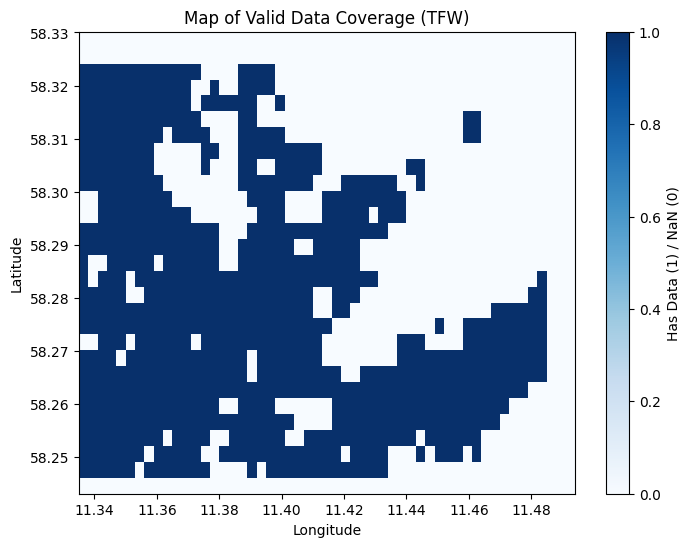


Examine the map above to visually pick a coordinate (blue area) to plot.


In [19]:
# ============================================================
# DATA COVERAGE MAP
# ============================================================
# Creates a spatial map showing which pixels contain valid
# (non-NaN) model output vs which are all-NaN (land or where
# all inputs were missing). Blue pixels = valid model output;
# white pixels = no data. Use this map to identify regions
# suitable for aquaculture analysis.

# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

In [22]:
# ============================================================
# SINGLE-POINT TIME SERIES PLOTS

ds_out = xr.open_dataset(output_file_name)
ds_out

<xarray.Dataset> Size: 71MB
Dimensions:             (latitude: 29, longitude: 53, time: 578)
Coordinates:
  * latitude            (latitude) float64 232B 58.33 58.33 ... 58.25 58.24
  * longitude           (longitude) float64 424B 11.34 11.34 ... 11.49 11.49
  * time                (time) datetime64[ns] 5kB 2020-02-01 ... 2021-08-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 7MB ...
    shell_energy        (latitude, longitude, time) float64 7MB ...
    aging               (latitude, longitude, time) float64 7MB ...
    C1                  (latitude, longitude, time) float64 7MB ...
    C2                  (latitude, longitude, time) float64 7MB ...
    C3                  (latitude, longitude, time) float64 7MB ...
    Chl_state           (latitude, longitude, time) float64 7MB ...
    O2                  (latitude, longitude, time) float64 7MB ...
    TFW                 (latitude, longitude, time) float64 7MB ...
    SL                  (latitude, longitude, time) float64 7MB ...
Attributes:
    units:      degC
    long_name:  Sea surface temperature

Plotting time series for point: Lat=58.258995, Lon=11.346692
Nearest pixel found at: Lat=58.260, Lon=11.346


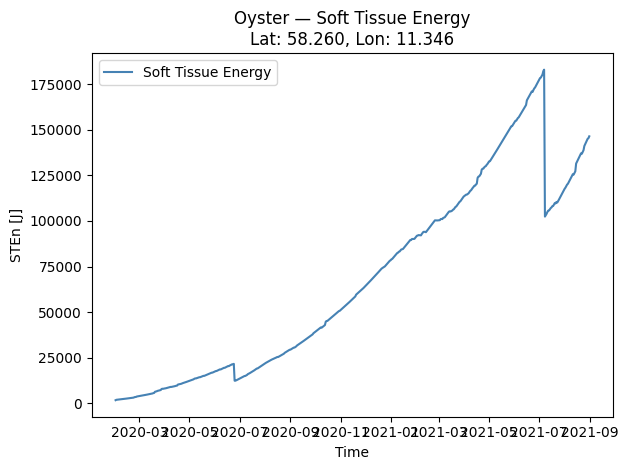

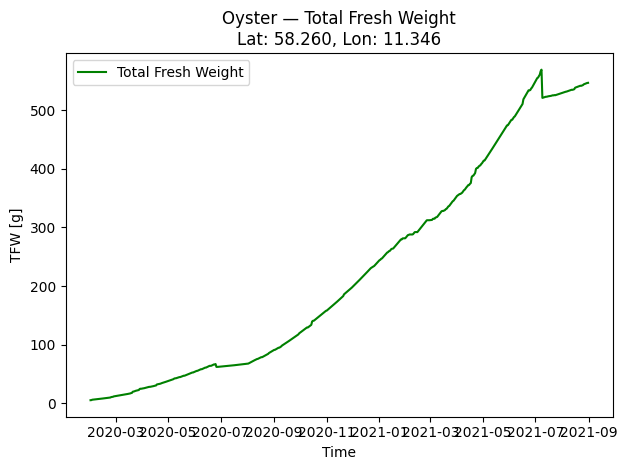

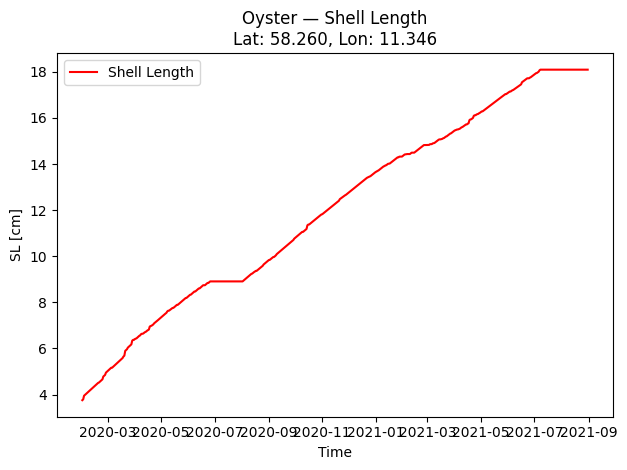

In [21]:



ds_out = ds_out.where(ds_out > -90)          # mask ShellSIM -99 sentinels
for var in ds_out.data_vars:
    ds_out[var] = ds_out[var].where(np.isfinite(ds_out[var].values))


plot_lat = 58.258995
plot_lon = 11.346692
print(f"Plotting time series for point: Lat={plot_lat}, Lon={plot_lon}")

try:
    single_point_data = ds_out.sel(
        latitude=plot_lat,
        longitude=plot_lon,
        method='nearest'
    ).load()

    actual_lat = float(single_point_data.latitude)
    actual_lon = float(single_point_data.longitude)
    print(f"Nearest pixel found at: Lat={actual_lat:.3f}, Lon={actual_lon:.3f}")

    all_nan = single_point_data.soft_tissue_energy.isnull().all()
    if all_nan:
        print("⚠️  Data at this point is all NaN (land or missing input data).")
        print("   Try a different coordinate — see the data coverage map cell.")

    # ── Plot 1: Soft Tissue Energy ──
    fig1, ax1 = plt.subplots()
    ax1.plot(single_point_data.time, single_point_data.soft_tissue_energy,
             label='Soft Tissue Energy', color='steelblue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('STEn [J]')
    ax1.set_title(f'Oyster — Soft Tissue Energy\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax1.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Total Fresh Weight ──
    fig2, ax2 = plt.subplots()
    ax2.plot(single_point_data.time, single_point_data.TFW,
             label='Total Fresh Weight', color='green')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('TFW [g]')
    ax2.set_title(f'Oyster — Total Fresh Weight\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Shell Length ──
    fig3, ax3 = plt.subplots()
    ax3.plot(single_point_data.time, single_point_data.SL,
             label='Shell Length', color='red')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('SL [cm]')
    ax3.set_title(f'Oyster — Shell Length\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax3.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error selecting data for plotting: {e}")
    print("Check that the output file exists and the coordinates fall within the domain.")

# Compare Insitu and Satellite Data (Chl, Temp, Salinity)

In [24]:
subset_area_bbox = (11.444389, 58.256528, 11.444389, 58.256528)

In [25]:
# ============================================================
# SUBSET SATELLITE INPUT TO THE IN-SITU POINT + LOAD EXCEL FORCING
# ============================================================
# subset_area_bbox is a degenerate box (min == max) = the single
# in-situ mooring location in Gullmarsfjord. Take its centre and
# pull the nearest satellite pixel's daily Chl / T / S time series,
# then load the matching in-situ measurements from the Excel file.

EXCEL_FILE = "Environmental Data for PML.xlsx"   # 

min_lon_s, min_lat_s, max_lon_s, max_lat_s = subset_area_bbox
center_lon = (min_lon_s + max_lon_s) / 2.0
center_lat = (min_lat_s + max_lat_s) / 2.0
print(f"In-situ point  : lat={center_lat:.6f}, lon={center_lon:.6f}")

# -- Nearest satellite pixel -> daily series as pandas (indexed by date) --
sat_pt = ds_daily.sel(latitude=center_lat, longitude=center_lon,
                      method='nearest').load()
print(f"Nearest sat px : lat={float(sat_pt.latitude):.4f}, lon={float(sat_pt.longitude):.4f}")

sat_time = pd.to_datetime(sat_pt.time.values)
sat_chl  = pd.Series(np.asarray(sat_pt['Chl'].values,         float), index=sat_time, name='sat_Chl')
sat_temp = pd.Series(np.asarray(sat_pt['temperature'].values, float), index=sat_time, name='sat_T')
sat_sal  = pd.Series(np.asarray(sat_pt['salinity'].values,    float), index=sat_time, name='sat_S')

# -- In-situ forcing from Excel --
chl_insitu = pd.read_excel(EXCEL_FILE, sheet_name='CPr food Chl 3m')
chl_insitu = chl_insitu.rename(columns={'!date': 'date'})[['date', 'Chl']].dropna()
chl_insitu['date'] = pd.to_datetime(chl_insitu['date'])

env_insitu = pd.read_excel(EXCEL_FILE, sheet_name='CPr Env 3m')
env_insitu = env_insitu.rename(columns={'!date': 'date'})[['date', 'T', 'S']].dropna()
env_insitu['date'] = pd.to_datetime(env_insitu['date'])

print(f"In-situ Chl    : {len(chl_insitu)} points "
      f"({chl_insitu.date.min().date()} -> {chl_insitu.date.max().date()})")
print(f"In-situ T/S    : {len(env_insitu)} points "
      f"({env_insitu.date.min().date()} -> {env_insitu.date.max().date()})")
print(f"Satellite      : {len(sat_time)} daily steps "
      f"({sat_time.min().date()} -> {sat_time.max().date()})")

In-situ point  : lat=58.256528, lon=11.444389
Nearest sat px : lat=58.2566, lon=11.4445
In-situ Chl    : 45 points (2019-06-17 -> 2021-08-16)
In-situ T/S    : 855 points (2019-01-22 -> 2021-08-23)
Satellite      : 578 daily steps (2020-02-01 -> 2021-08-31)


=== Forcing comparison (satellite sampled at in-situ dates, +/-3 days) ===
  Chl : n= 30  RMSE=2.270  bias=+1.139  MAE=1.894  r=0.16
  T   : n=573  RMSE=5.654  bias=+0.494  MAE=4.759  r=0.48
  S   : n=573  RMSE=4.216  bias=-0.079  MAE=3.465  r=-0.05


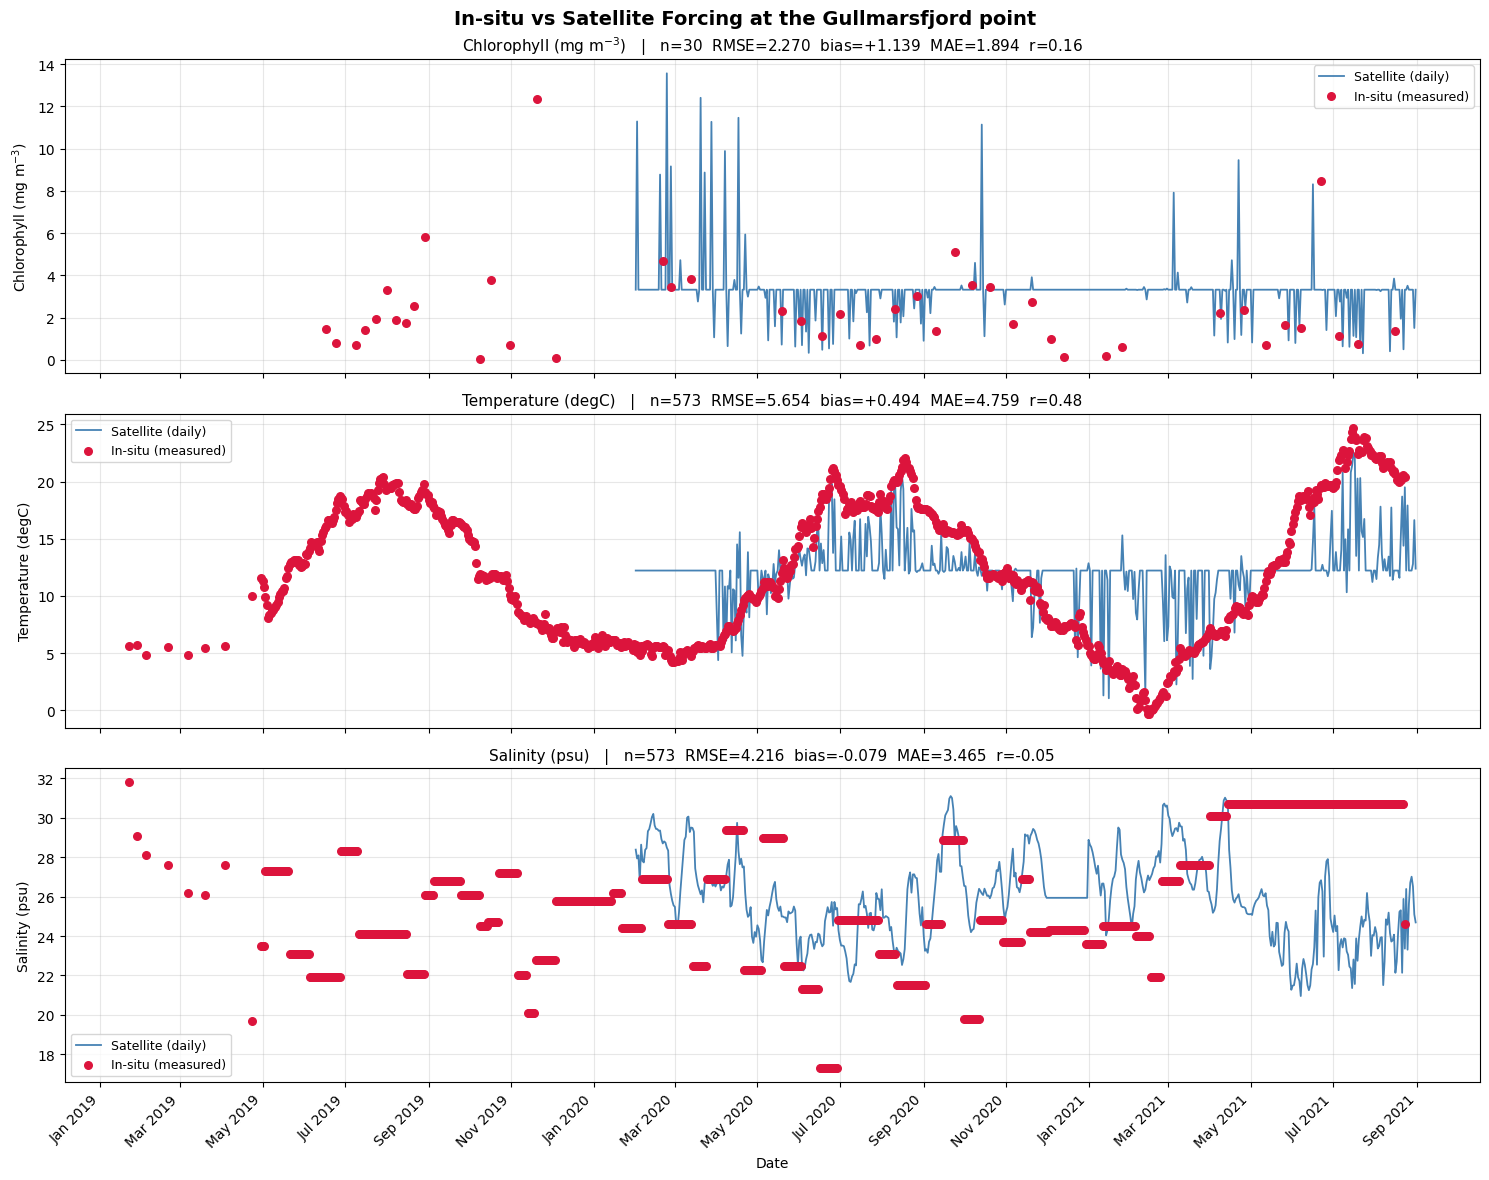

In [26]:
# ============================================================
# COMPARE FORCING: IN-SITU vs SATELLITE  (Chl, Temperature, Salinity)
# ============================================================
# Satellite = continuous daily line; in-situ = measured markers.
# Skill stats are computed by sampling the satellite series at each
# in-situ sampling date (nearest day, within +/- tol_days).

def _align_to_insitu(sat_series, ins_dates, ins_vals, tol_days=3):
    """Match satellite values to in-situ dates (nearest); return (matched, stats)."""
    ins_dates = pd.to_datetime(pd.Index(ins_dates))
    s = sat_series.dropna().sort_index()
    matched = np.full(len(ins_dates), np.nan)
    if len(s):
        pos = s.index.get_indexer(ins_dates, method='nearest')
        for k, (i, d) in enumerate(zip(pos, ins_dates)):
            if i != -1 and abs((s.index[i] - d).days) <= tol_days:
                matched[k] = s.iloc[i]
    obs = np.asarray(ins_vals, float)
    m = np.isfinite(matched) & np.isfinite(obs)
    if m.sum() == 0:
        return matched, dict(n=0, rmse=np.nan, bias=np.nan, mae=np.nan, r=np.nan)
    d = matched[m] - obs[m]
    stats = dict(n=int(m.sum()),
                 rmse=float(np.sqrt(np.mean(d**2))),
                 bias=float(np.mean(d)),
                 mae=float(np.mean(np.abs(d))),
                 r=float(np.corrcoef(matched[m], obs[m])[0, 1]) if m.sum() > 1 else np.nan)
    return matched, stats

specs = [
    ('Chlorophyll (mg m$^{-3}$)', sat_chl,  chl_insitu['date'], chl_insitu['Chl'], 'Chl'),
    ('Temperature (degC)',        sat_temp, env_insitu['date'], env_insitu['T'],   'T'),
    ('Salinity (psu)',            sat_sal,  env_insitu['date'], env_insitu['S'],   'S'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
print('=== Forcing comparison (satellite sampled at in-situ dates, +/-3 days) ===')
forcing_stats = {}
for ax, (label, sat_s, idate, ival, key) in zip(axes, specs):
    ax.plot(sat_s.index, sat_s.values, color='steelblue', lw=1.3, label='Satellite (daily)')
    ax.scatter(idate, ival, color='crimson', s=30, zorder=5, label='In-situ (measured)')
    _, st = _align_to_insitu(sat_s, idate, ival)
    forcing_stats[key] = st
    ax.set_ylabel(label)
    ax.set_title(f"{label}   |   n={st['n']}  RMSE={st['rmse']:.3f}  "
                 f"bias={st['bias']:+.3f}  MAE={st['mae']:.3f}  r={st['r']:.2f}",
                 fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    print(f"  {key:4s}: n={st['n']:3d}  RMSE={st['rmse']:.3f}  "
          f"bias={st['bias']:+.3f}  MAE={st['mae']:.3f}  r={st['r']:.2f}")

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
for t in axes[-1].get_xticklabels():
    t.set_rotation(45); t.set_ha('right')
plt.suptitle('In-situ vs Satellite Forcing at the Gullmarsfjord point',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare Outputs Insitu and Satellite Data (Shell Length and TFW)

In [27]:
# ============================================================
# SUBSET MODEL OUTPUT TO THE IN-SITU POINT (centre of subset_area_bbox)
# ============================================================
ds_out = xr.open_dataset(output_file_name)
ds_out = ds_out.where(ds_out > -90)   # mask ShellSIM -99 sentinels

# Use the same centre point as the input comparison above
out_pt = ds_out.sel(latitude=center_lat, longitude=center_lon,
                    method='nearest').load()
print(f"Model output pixel: lat={float(out_pt.latitude):.4f}, lon={float(out_pt.longitude):.4f}")

out_time  = pd.to_datetime(out_pt.time.values)
model_tfw = pd.Series(np.asarray(out_pt['TFW'].values, float), index=out_time, name='model_TFW')
model_sl  = pd.Series(np.asarray(out_pt['SL'].values,  float), index=out_time, name='model_SL')

def _rng(s):
    v = s.values[np.isfinite(s.values)]
    return (np.nan, np.nan) if v.size == 0 else (float(v.min()), float(v.max()))

tlo, thi = _rng(model_tfw); slo, shi = _rng(model_sl)
print(f"Model TFW range : {tlo:.3f} -> {thi:.3f} g")
print(f"Model SL  range : {slo:.3f} -> {shi:.3f} cm")
if model_tfw.notna().sum() == 0:
    print("WARNING: model output is all-NaN at this pixel (land / missing forcing).")

Model output pixel: lat=58.2566, lon=11.4445
Model TFW range : 5.000 -> 2192.177 g
Model SL  range : 3.757 -> 28.317 cm


In [28]:
# ============================================================
# LOAD IN-SITU GROWTH (TFW, SL) FOR ALL 3 SPECIES
# ============================================================
# Long format: date, species, depth, [size_class], metric, value.
#   MG (Magallana gigas)  & OE (Ostrea edulis) are size-sorted (S/M/L)
#   ME (Mytilus edulis)   is NOT size-sorted -> treated as a single cohort
TFW_METRIC = 'TFW (g)'
SL_METRIC  = 'SL (cm)'

SPECIES_SHEET = {'MG': 'CPr MG 3m', 'OE': 'CPr OE 3m', 'ME': 'CPr ME 3m'}
SPECIES_NAME  = {'MG': 'Magallana gigas', 'OE': 'Ostrea edulis', 'ME': 'Mytilus edulis'}

def _load_species(sheet):
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    df['date'] = pd.to_datetime(df['date'])
    if 'size_class' not in df.columns:      # ME has no size class
        df['size_class'] = 'all'
    return df

insitu_bio = {code: _load_species(sh) for code, sh in SPECIES_SHEET.items()}

def get_insitu_series(df, metric, size_class):
    """Return (dates, values) for one metric & size class, sorted by date."""
    sub = df[(df['metric'] == metric) & (df['size_class'] == size_class)].sort_values('date')
    return sub['date'].values, sub['value'].values.astype(float)

for code, df in insitu_bio.items():
    scs = sorted(df['size_class'].unique().tolist())
    print(f"{code} ({SPECIES_NAME[code]:>16s}): {len(df):3d} rows | size classes={scs} | "
          f"{df.date.min().date()} -> {df.date.max().date()}")

MG ( Magallana gigas):  78 rows | size classes=['L', 'M', 'S'] | 2019-01-16 -> 2021-08-31
OE (   Ostrea edulis):  66 rows | size classes=['L', 'M', 'S'] | 2019-04-04 -> 2021-08-24
ME (  Mytilus edulis):  26 rows | size classes=['all'] | 2020-07-22 -> 2021-08-16


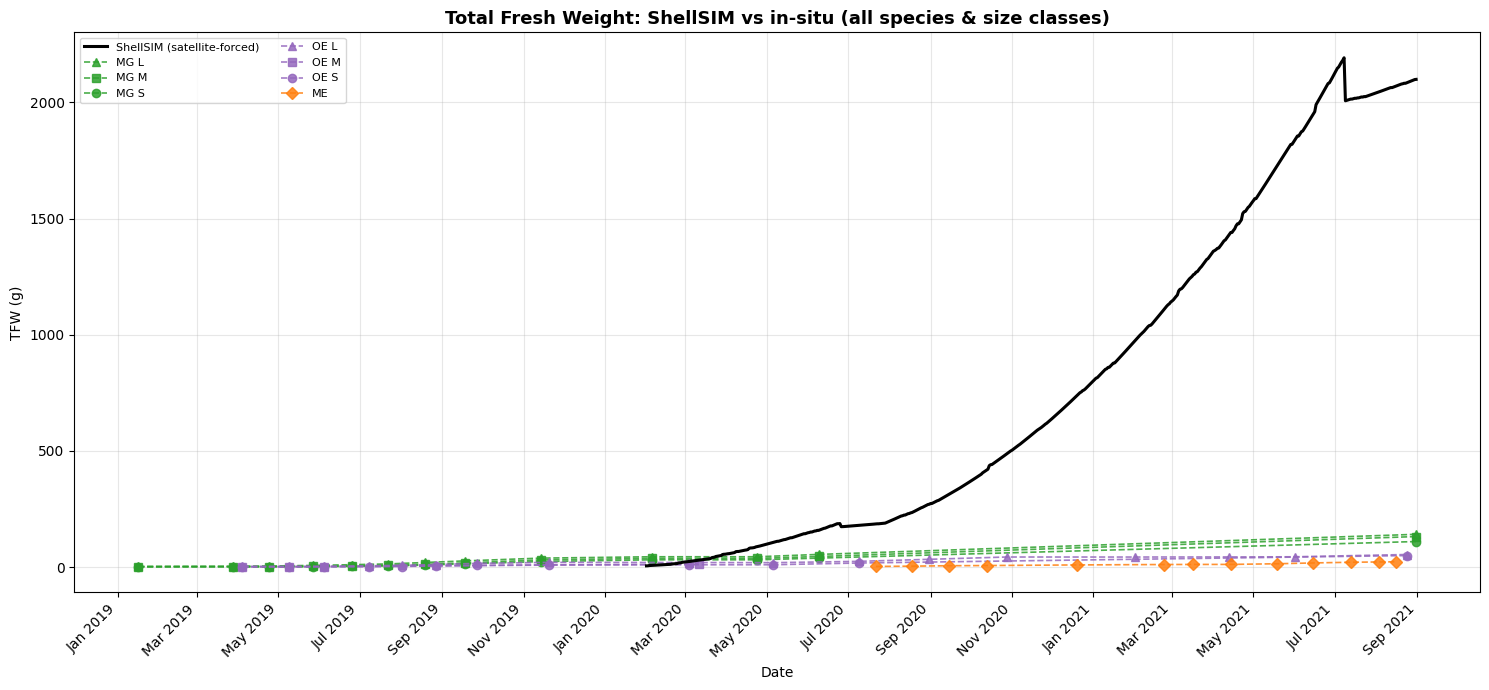

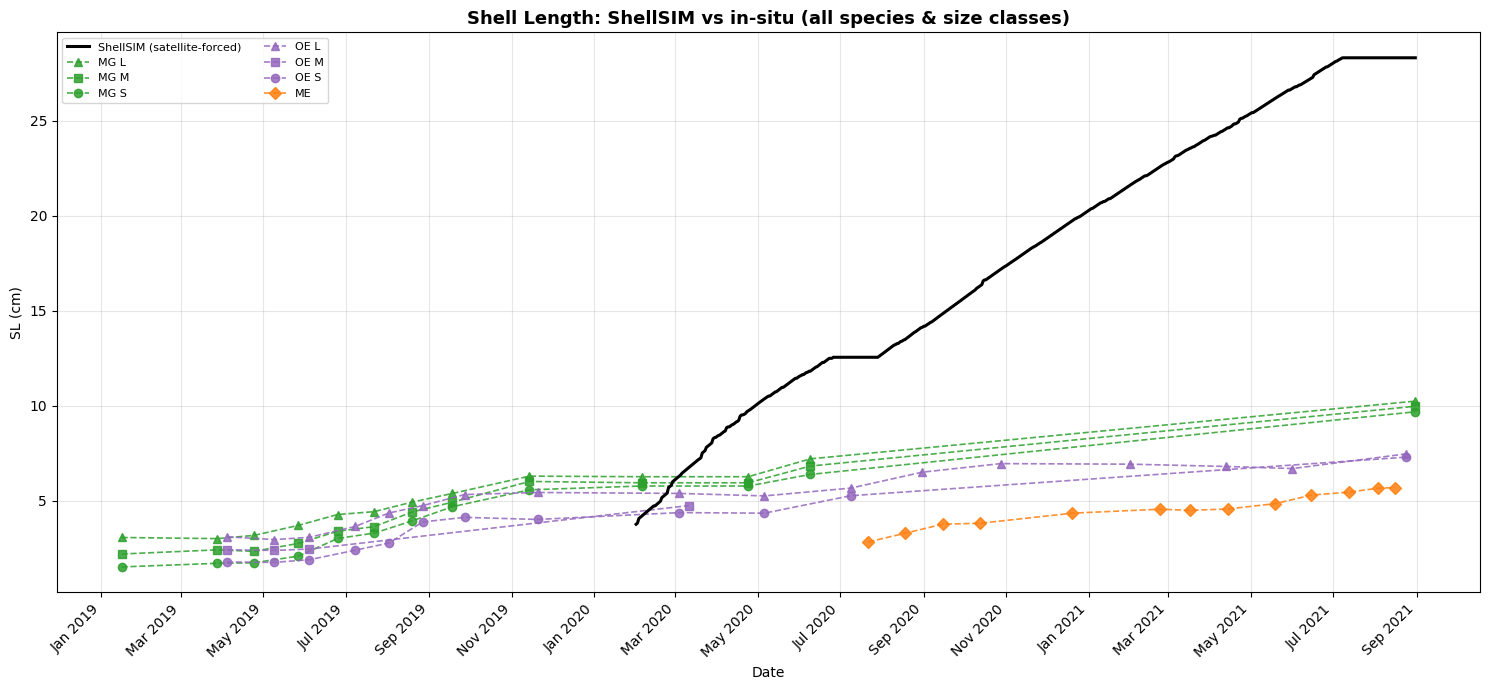

In [29]:
# ============================================================
# PLOT: MODEL (satellite-forced) vs IN-SITU GROWTH TRAJECTORIES
# ============================================================
# One figure per metric. Black line = ShellSIM at the in-situ pixel;
# dashed coloured markers = measured cohorts (species x size class).
size_markers   = {'S': 'o', 'M': 's', 'L': '^', 'all': 'D'}
species_colors = {'MG': 'tab:green', 'OE': 'tab:purple', 'ME': 'tab:orange'}

for metric, model_series, ylab, title in [
    (TFW_METRIC, model_tfw, 'TFW (g)', 'Total Fresh Weight'),
    (SL_METRIC,  model_sl,  'SL (cm)', 'Shell Length'),
]:
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(model_series.index, model_series.values, color='black', lw=2.2,
            label='ShellSIM (satellite-forced)', zorder=6)
    for code, df in insitu_bio.items():
        for sc in sorted(df['size_class'].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            lbl = f"{code} {sc}" if sc != 'all' else code
            ax.plot(d, v, marker=size_markers.get(sc, 'x'), ls='--', ms=6,
                    lw=1.2, color=species_colors[code], alpha=0.85, label=lbl)
    ax.set_ylabel(ylab); ax.set_xlabel('Date')
    ax.set_title(f'{title}: ShellSIM vs in-situ (all species & size classes)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=2, loc='best')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    for t in ax.get_xticklabels():
        t.set_rotation(45); t.set_ha('right')
    plt.tight_layout()
    plt.show()

In [30]:
# ============================================================
# WHICH SPECIES DOES THE MODEL TRACK BEST?
# ============================================================
# Sample the ShellSIM trajectory at each in-situ sampling date
# (nearest day, +/- tol_days) and score against every cohort
# (species x size class) for TFW and SL: RMSE / MAE / bias / r.
# Lower RMSE => model growth is closer to that shellfish type.

def _match_model(model_series, dates, tol_days=7):
    s = model_series.dropna().sort_index()
    dates = pd.to_datetime(pd.Index(dates))
    out = np.full(len(dates), np.nan)
    if len(s):
        pos = s.index.get_indexer(dates, method='nearest')
        for k, (i, d) in enumerate(zip(pos, dates)):
            if i != -1 and abs((s.index[i] - d).days) <= tol_days:
                out[k] = s.iloc[i]
    return out

rows = []
for metric, model_series in [(TFW_METRIC, model_tfw), (SL_METRIC, model_sl)]:
    for code, df in insitu_bio.items():
        for sc in sorted(df['size_class'].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            mod = _match_model(model_series, d)
            obs = np.asarray(v, float)
            m = np.isfinite(mod) & np.isfinite(obs)
            if m.sum() == 0:
                continue
            diff = mod[m] - obs[m]
            rows.append({
                'metric': metric, 'species': code,
                'species_name': SPECIES_NAME[code], 'size_class': sc,
                'n': int(m.sum()),
                'RMSE': float(np.sqrt(np.mean(diff**2))),
                'MAE':  float(np.mean(np.abs(diff))),
                'bias': float(np.mean(diff)),
                'r':    float(np.corrcoef(mod[m], obs[m])[0, 1]) if m.sum() > 1 else np.nan,
            })

cmp = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

for metric in [TFW_METRIC, SL_METRIC]:
    sub = cmp[cmp.metric == metric].sort_values('RMSE').reset_index(drop=True)
    print(f"\n{'='*78}\n  {metric}: ShellSIM vs in-situ cohorts (sorted by RMSE, lower = closer)\n{'='*78}")
    if sub.empty:
        print('  No overlapping data to compare.')
        continue
    print(sub[['species', 'species_name', 'size_class', 'n',
               'RMSE', 'MAE', 'bias', 'r']].to_string(index=False))
    # Best cohort per species, then overall best
    per_sp = sub.loc[sub.groupby('species')['RMSE'].idxmin()].sort_values('RMSE')
    best = per_sp.iloc[0]
    print(f"\n  Best match per species (closest size class): " +
          ', '.join(f"{r.species}({r.size_class})={r.RMSE:.2f}" for _, r in per_sp.iterrows()))
    print(f"  => Model {metric} is CLOSEST to: {best.species} "
          f"({best.species_name}), size class '{best.size_class}'  [RMSE={best.RMSE:.3f}]")

print(f"\n{'='*78}")
print("  NOTE: RMSE is in each metric's own units (g for TFW, cm for SL).")
print("  Cohorts are seeded at different sizes, so compare trajectory SHAPE")
print("  (r, bias) alongside RMSE when judging which species the model mimics.")


  TFW (g): ShellSIM vs in-situ cohorts (sorted by RMSE, lower = closer)
species    species_name size_class  n     RMSE      MAE     bias     r
     OE   Ostrea edulis          M  1   16.661   16.661   16.661   NaN
     MG Magallana gigas          L  4  981.014  535.710  517.085 0.998
     MG Magallana gigas          M  4  986.097  540.350  525.225 0.999
     MG Magallana gigas          S  4  997.029  547.447  535.367 0.999
     OE   Ostrea edulis          S  4 1022.033  576.874  576.874 0.990
     OE   Ostrea edulis          L  9 1075.869  785.524  785.524 0.866
     ME  Mytilus edulis        all 13 1376.387 1180.762 1180.762 0.965

  Best match per species (closest size class): OE(M)=16.66, MG(L)=981.01, ME(all)=1376.39
  => Model TFW (g) is CLOSEST to: OE (Ostrea edulis), size class 'M'  [RMSE=16.661]

  SL (cm): ShellSIM vs in-situ cohorts (sorted by RMSE, lower = closer)
species    species_name size_class  n   RMSE    MAE   bias     r
     OE   Ostrea edulis          M  1  2.002  